# 54 - Code Challenge: Reproducible Random Weights

**Section:** Weight Initialization | **Prereqs:** `Weight Initialization/BaseWeightInitailzation.ipynb` | **Next:** `Weight Initialization/KiamingAndXaviarInitialization.ipynb`

Four models: one unseeded, one seeded 24, and two seeded 42. Plot every weight
and see which lines up.

**The result:** the two seed-42 models are *identical*, element for element.
Random number generation in PyTorch is deterministic given a seed - 'random' means
unpredictable, not irreproducible.

**Why this matters in practice**
- **Reproducibility.** Seed before initialising and your run can be repeated
  exactly - essential for debugging and for anyone re-running your work.
- **Fair comparison.** Comparing two architectures without a seed means part of
  the difference you measure is initialisation luck. Seed both, or better, run
  each several times and compare distributions.
- **Not a substitute for repetition.** A single seeded run is still one sample.
  Seeding makes it repeatable, not representative.

**Where to call `torch.manual_seed`:** once, before the model is built. This
notebook calls it inside the parameter loop, which reseeds before every layer -
harmless here, but it means every layer of the same shape gets the same weights.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [67]:
# A factory so every model starts from the same architecture.
def make_model():
  return nn.Sequential(nn.Linear(2,8),
                       nn.ReLU(),
                       nn.Linear(8,8),
                       nn.ReLU(),
                       nn.Linear(8,1)
                       )

In [68]:
# No seed: xavier_normal_ draws from wherever the global RNG currently is.
# The trailing underscore in nn.init.xavier_normal_ marks an IN-PLACE op - it
# overwrites the parameter rather than returning a new tensor.
model_no_seed = make_model()

for pname, yparams in model_no_seed.named_parameters():
  if 'weight' in pname:
    nn.init.xavier_normal_(yparams)

In [69]:
# Seeded with 24.
# Note manual_seed is called INSIDE the loop, so the RNG is reset before every
# layer - meaning two layers of the same shape receive identical weights.
# Calling it once before make_model() is the usual pattern.
model_rs_2 = make_model()

for pname, yparams in model_rs_2.named_parameters():
  if 'weight' in pname:
    torch.manual_seed(24)
    nn.init.xavier_normal_(yparams)

In [70]:
# Seeded 42.
model_rs_1a = make_model()

for pname, yparams in model_rs_1a.named_parameters():
  if 'weight' in pname:
    torch.manual_seed(42)
    nn.init.xavier_normal_(yparams)

In [71]:
# Seeded 42 again - a separate model object, same seed.
model_rs_1b = make_model()

for pname, yparams in model_rs_1b.named_parameters():
  if 'weight' in pname:
    torch.manual_seed(42)
    nn.init.xavier_normal_(yparams)

In [72]:
# Flatten every weight from each model into one long vector for comparison.
rs_1a = []
rs_1b = []
rs_no = []
rs_2 = []

for pname, yparams in model_rs_1a.named_parameters():
  if 'weight' in pname:
    rs_1a = np.concatenate((rs_1a, yparams.data.detach().flatten().numpy()), axis=0)


for pname, yparams in model_rs_1b.named_parameters():
  if 'weight' in pname:
    rs_1b = np.concatenate((rs_1b, yparams.data.detach().flatten().numpy()), axis=0)


for pname, yparams in model_no_seed.named_parameters():
  if 'weight' in pname:
    rs_no = np.concatenate((rs_no, yparams.data.detach().flatten().numpy()), axis=0)


for pname, yparams in model_rs_2.named_parameters():
  if 'weight' in pname:
    rs_2 = np.concatenate((rs_2, yparams.data.detach().flatten().numpy()), axis=0)



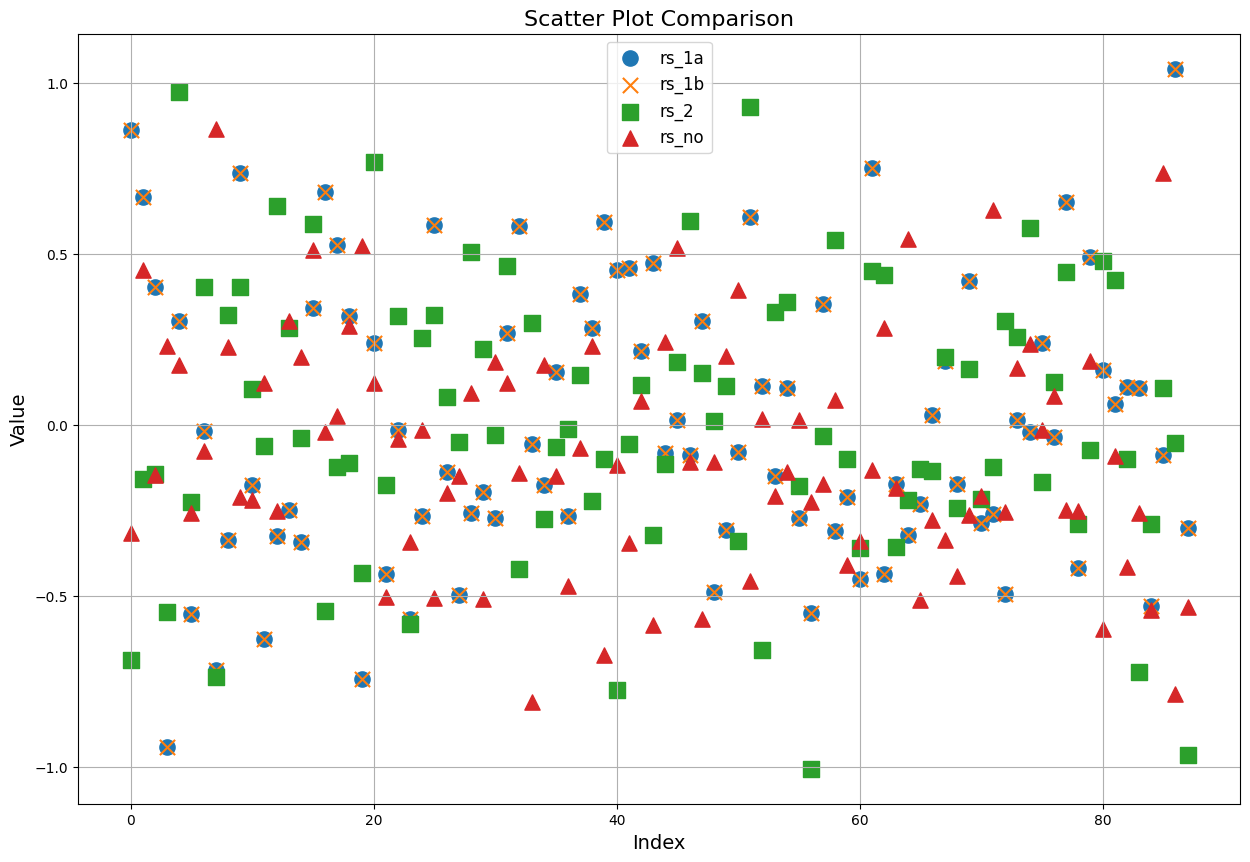

In [81]:
# The plot. rs_1a and rs_1b (both seed 42) coincide exactly at every index;
# rs_2 and rs_no lie elsewhere.
# Same seed = same weights, always. That is the whole finding, and it is what
# makes an experiment reproducible.
plt.figure(figsize=(15, 10))

plt.scatter(
    range(len(rs_1a)),
    rs_1a,
    label="rs_1a",
    s=120
)

plt.scatter(
    range(len(rs_1b)),
    rs_1b,
    marker='x',
    label="rs_1b",
    s=120
)

plt.scatter(
    range(len(rs_2)),
    rs_2,
    marker='s',
    label="rs_2",
    s=120
)

plt.scatter(
    range(len(rs_no)),
    rs_no,
    marker='^',
    label="rs_no",
    s=120
)

plt.xlabel("Index", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.title("Scatter Plot Comparison", fontsize=16)

plt.legend(fontsize=12)
plt.grid(True)

plt.show()
